# Time Series

In [ ]:
#
# Import libraries
#
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

## Part 1 - Load and prepare the data

In [3]:
#
# Load data
#
df = pd.read_csv('AirPassengers.csv')
print('Dataset dimensions:', df.shape)
print('Columns:', df.columns)
print('Data Types:\n', df.dtypes)
df.head(10)

Dataset dimensions: (144, 2)
Columns: Index(['TimePeriod', 'Passengers'], dtype='object')
Data Types:
 TimePeriod    object
Passengers     int64
dtype: object


,TimePeriod,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [4]:
#
# Let's drop date column
#
df.drop(columns=['TimePeriod'], inplace=True)
print('Dataset dimensions:', df.shape)
df.head(5)

Dataset dimensions: (144, 1)


,Passengers
0,112
1,118
2,132
3,129
4,121


In [5]:
#
# Convert data frame into time series object
#
dates = pd.date_range(start='1949-01-01', freq='MS', periods=len(df))
# print(dates)
#
# set these dates as the index of the dataframe
df.set_index(dates, inplace=True)
data = df

In [6]:
#
# Remove the original dataset
#
del dates, df

In [7]:
#
# Preview TS object
#
data

,Passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390


# Part 2 - Visualise and decompose TS

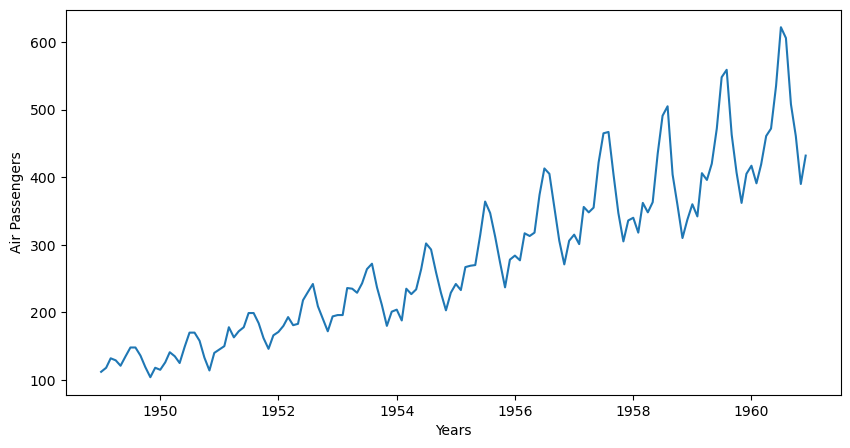

In [8]:
#
# Visualise the original dataset
#
plt.figure(figsize=(10, 5))
plt.plot(data)
plt.xlabel('Years')
plt.ylabel('Air Passengers')
plt.show()

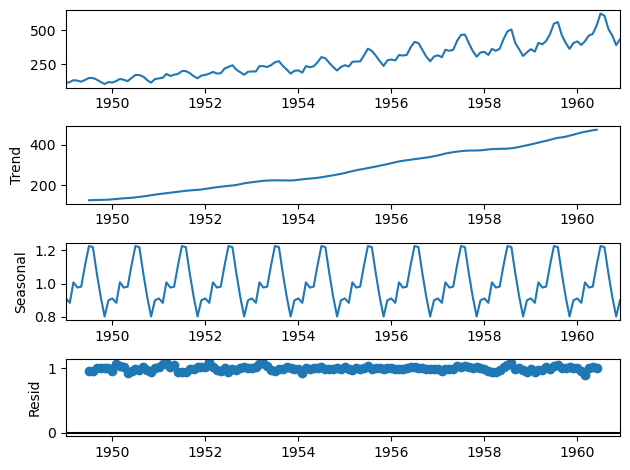

In [9]:
#
# Decompose TS into three components
#
from statsmodels.tsa.seasonal import seasonal_decompose
components = seasonal_decompose(data, model='multiplicative', period=12)
components.plot()
plt.show()
del components, seasonal_decompose
#
# Good resource on TS decomposition:
# https://anomaly.io/seasonal-trend-decomposition-in-r/index.html
#

# Part 3 - Analysis

In [10]:
#
# Split the dataset into training and testing subsets:
# * the first 132 values - training,
# * the last 12 values   - testing
#
train = data.iloc[:132]
test  = data.iloc[132:]

In [11]:
#
# First of all, let's try running ARIMA in auto mode
#
MODEL_ARIMA_Auto = pm.auto_arima(train, m=12)

In [12]:
#
# View the model
#
MODEL_ARIMA_Auto.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -447.843
Date:                            Tue, 18 Feb 2025   AIC                            905.686
Time:                                    23:46:20   BIC                            919.623
Sample:                                01-01-1949   HQIC                           911.346
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.5341      2.007      2.757      0.006       1.600       9.468
ar.L1          0.7049      0.095      7.393      0.000       0.518       0.892
ar.L2          0.2574      0.131      1.968      0.049       0.001       0.514
ar.L3         -0.1434      0.107     -1.338      0.181      -0.354       0.067
sigma2       101.0969     12.818      7.887      0.000      75.974     126.220
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.83
Prob(Q):                              0.96   Prob(JB):                         0.24
Heteroskedasticity (H):               1.41   Skew:                            -0.14
Prob(H) (two-sided):                  0.29   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
#
# Run the model (in auto mode) to predict the last 12 values
#
forecast = MODEL_ARIMA_Auto.predict(12)
forecast

1960-01-01    419.967172
1960-02-01    399.849851
1960-03-01    457.994382
1960-04-01    444.474157
1960-05-01    464.789180
1960-06-01    514.125442
1960-07-01    587.804171
1960-08-01    597.010824
1960-09-01    499.531270
1960-10-01    442.359680
1960-11-01    396.410218
1960-12-01    438.651596
Freq: MS, dtype: float64

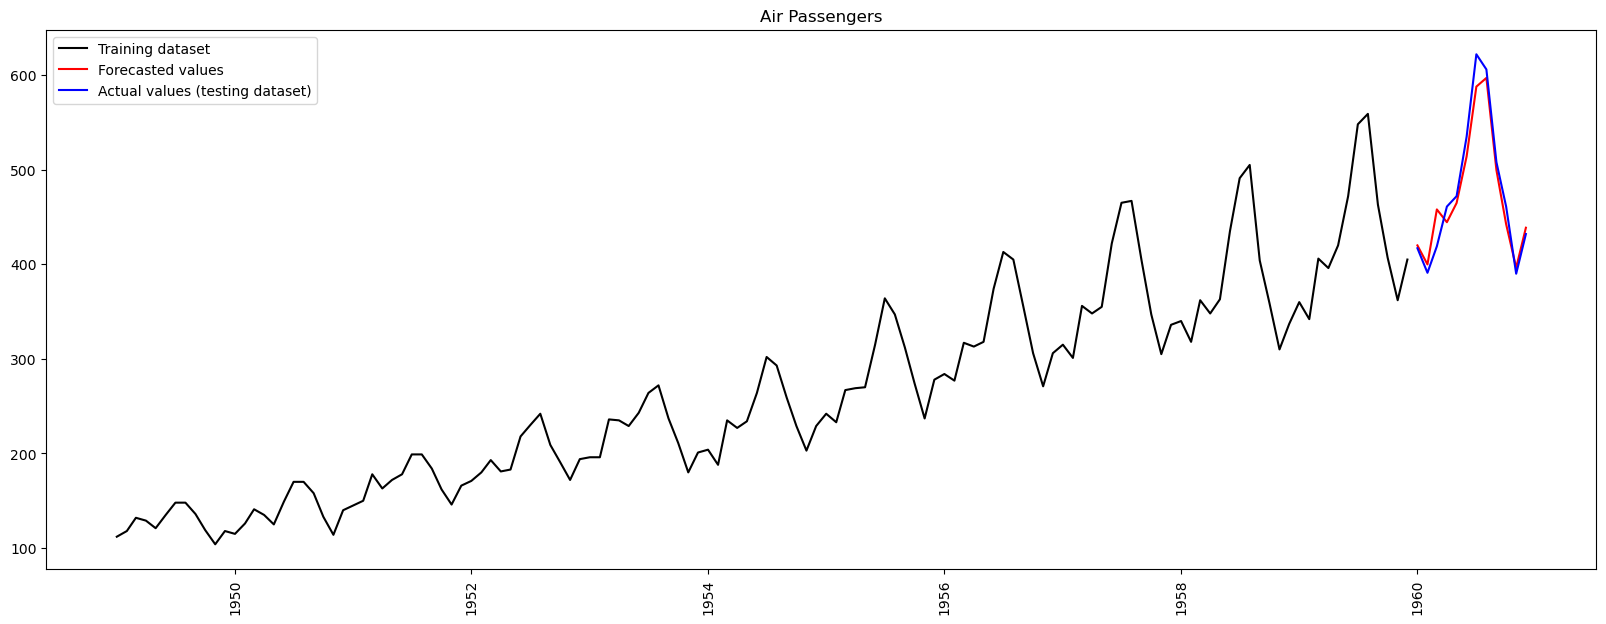

In [14]:
#
# Plot forecasted values against the actual ones
#
# training dataset in black,
# forecasted values in red,
# actual (true) values in blue
#
plt.figure(figsize = (20,7))
plt.title('Air Passengers')
plt.plot(data.index[:132], train,    c='black', label = 'Training dataset')
plt.plot(data.index[132:], forecast, c='red',   label = 'Forecasted values')
plt.plot(data.index[132:], test,     c='blue',  label = 'Actual values (testing dataset)')
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [15]:
#
# Results
#
# Looks like Python implementation of auto arima
# mananged to build the model and predict the values
# (therefore is made TS stationary without any effort from us)
#
# Let's calculate its quality

# Mean Absolute Error (MAE)
MAE = (abs(forecast - test['Passengers'])).mean()
print('The Mean Absolute Error of the auto arima forecasts is:', round(MAE, 2))

The Mean Absolute Error of the auto arima forecasts is: 14.9


- "The Mean Absolute Error of the Auto ARIMA forecasts is 14.9"
- MAE measures the average absolute difference between your actual values and forecasted values.
- It tells you, on average, how far off your predictions are from the actual values.
- Lower MAE = better model performance (smaller errors).

In [ ]:
# Mean Absolute Percentage Error (MAPE)
MAPE = ((abs(forecast - test['Passengers'])/abs(test['Passengers'])).mean())*100
print('The Mean Absolute Percentage Error of the auto arima forecasts is:', round(MAPE, 2),'%')

- "The Mean Absolute Percentage Error of the Auto ARIMA forecasts is 3.1%"
- MAPE measures the average percentage difference between actual and predicted values.
- It tells you, in percentage terms, how far off your forecasts are.
- Lower MAPE = better forecasting accuracy.